In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)


In [3]:
# carregando todos os arquivos csv originais do CIC-IDS2017
# mesmo procedimento das etapas 1, 2 e 3
dados_caminho = "../dados/dados_nao_processados/"

arquivos_csv = [f for f in os.listdir(dados_caminho) if f.endswith(".csv")]
print(f"Arquivos encontrados: {len(arquivos_csv)}\n")

dataframes = []
for arquivo in arquivos_csv:
    print(f" Carregando: {arquivo}")
    df = pd.read_csv(
        os.path.join(dados_caminho, arquivo),
        encoding='utf-8',
        low_memory=False
    )
    dataframes.append(df)

df_total = pd.concat(dataframes, ignore_index=True)

# removendo espaços dos nomes das colunas (igual etapa 3)
df_total.columns = df_total.columns.str.strip()

print(f"\nDataset bruto carregado")
print(f" Registros: {df_total.shape[0]:,}")
print(f" Colunas:   {df_total.shape[1]}")

Arquivos encontrados: 8

 Carregando: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 Carregando: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 Carregando: Friday-WorkingHours-Morning.pcap_ISCX.csv
 Carregando: Monday-WorkingHours.pcap_ISCX.csv
 Carregando: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 Carregando: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 Carregando: Tuesday-WorkingHours.pcap_ISCX.csv
 Carregando: Wednesday-workingHours.pcap_ISCX.csv

Dataset bruto carregado
 Registros: 2,830,743
 Colunas:   79


In [4]:
# verificando os nomes exatos das classes no dataset
print("Classes disponíveis no dataset bruto:\n")
distribuicao_total = df_total['Label'].value_counts()
for classe, qtd in distribuicao_total.items():
    pct = (qtd / len(df_total)) * 100
    print(f"  {classe:30s} → {qtd:>10,} ({pct:.4f}%)")

# identificando as classes de interesse
# zero-day: Heartbleed e Infiltration (não vistas no treino)
# controle: BENIGN (para medir falsos positivos)
classes_zero_day_alvo = ['Heartbleed', 'Infiltration']
classe_controle_alvo = 'BENIGN'

classes_zero_day_encontradas = []
for alvo in classes_zero_day_alvo:
    correspondencias = [c for c in distribuicao_total.index if alvo.lower() in str(c).lower()]
    if correspondencias:
        classes_zero_day_encontradas.extend(correspondencias)
        print(f"\n Classe zero-day '{alvo}' encontrada como: {correspondencias}")
    else:
        print(f"\n Classe '{alvo}' não encontrada no dataset")

# buscando a classe BENIGN para o grupo de controle
classe_benign_encontrada = [c for c in distribuicao_total.index if classe_controle_alvo.lower() in str(c).lower()]
if classe_benign_encontrada:
    print(f"\n Classe de controle '{classe_controle_alvo}' encontrada como: {classe_benign_encontrada}")
else:
    print(f"\n Classe '{classe_controle_alvo}' não encontrada no dataset")

print(f"\nClasses zero-day a serem extraídas: {classes_zero_day_encontradas}")
print(f"Classe de controle a ser amostrada: {classe_benign_encontrada}")

Classes disponíveis no dataset bruto:

  BENIGN                         →  2,273,097 (80.3004%)
  DoS Hulk                       →    231,073 (8.1630%)
  PortScan                       →    158,930 (5.6144%)
  DDoS                           →    128,027 (4.5227%)
  DoS GoldenEye                  →     10,293 (0.3636%)
  FTP-Patator                    →      7,938 (0.2804%)
  SSH-Patator                    →      5,897 (0.2083%)
  DoS slowloris                  →      5,796 (0.2048%)
  DoS Slowhttptest               →      5,499 (0.1943%)
  Bot                            →      1,966 (0.0695%)
  Web Attack � Brute Force       →      1,507 (0.0532%)
  Web Attack � XSS               →        652 (0.0230%)
  Infiltration                   →         36 (0.0013%)
  Web Attack � Sql Injection     →         21 (0.0007%)
  Heartbleed                     →         11 (0.0004%)

 Classe zero-day 'Heartbleed' encontrada como: ['Heartbleed']

 Classe zero-day 'Infiltration' encontrada como: ['Infil

In [5]:
# filtrando os registros zero-day (Heartbleed e Infiltration)
df_zero_day = df_total[df_total["Label"].isin(classes_zero_day_encontradas)].copy()

print(f"Total de registros zero-day extraídos: {len(df_zero_day):,}\n")
print("Distribuição zero-day:")
print("=" * 50)
distribuicao_zd = df_zero_day['Label'].value_counts()
for classe, qtd in distribuicao_zd.items():
    pct = (qtd / len(df_zero_day)) * 100
    print(f"  {classe:30s} → {qtd:>6,} ({pct:.2f}%)")
print("=" * 50)

# amostra de 100 BENIGNs de controle NÃO vistos no treino
# para isso, replicamos a amostragem do treino (etapa 3) e excluímos esses índices
print("\nAmostragem do grupo de controle BENIGN (não vistos no treino)\n")

df_benign_total = df_total[df_total["Label"].isin(classe_benign_encontrada)].copy()
print(f"Total de BENIGNs no dataset bruto: {len(df_benign_total):,}")

# replicando a amostragem do treino: 2.500 BENIGNs com random_state=1
N_TREINO_BENIGN = 2500
SEED_TREINO = 1

benign_usados_no_treino = df_benign_total.sample(
    n=N_TREINO_BENIGN,
    random_state=SEED_TREINO
).index

print(f"BENIGNs reservados para o treino: {len(benign_usados_no_treino):,}")

# excluindo os índices do treino e amostrando 100 NOVOS BENIGNs
df_benign_disponivel = df_benign_total.drop(index=benign_usados_no_treino)
print(f"BENIGNs disponíveis (não vistos): {len(df_benign_disponivel):,}")

N_CONTROLE = 100
SEED_CONTROLE = 123  # seed diferente para não viciar com a do treino

df_benign_controle = df_benign_disponivel.sample(
    n=N_CONTROLE,
    random_state=SEED_CONTROLE
).copy()

print(f"\nBENIGNs de controle amostrados: {len(df_benign_controle):,}")
print(f"  Seed utilizada: {SEED_CONTROLE}")
print(f"  Garantia: nenhum desses registros está no treino")

Total de registros zero-day extraídos: 47

Distribuição zero-day:
  Infiltration                   →     36 (76.60%)
  Heartbleed                     →     11 (23.40%)

Amostragem do grupo de controle BENIGN (não vistos no treino)

Total de BENIGNs no dataset bruto: 2,273,097
BENIGNs reservados para o treino: 2,500
BENIGNs disponíveis (não vistos): 2,270,597

BENIGNs de controle amostrados: 100
  Seed utilizada: 123
  Garantia: nenhum desses registros está no treino


In [6]:
# aplicando a MESMA limpeza da etapa 3 nos dois conjuntos
print("Aplicando limpeza idêntica à do treino (etapa 3)\n")

def limpar_conjunto(df, nome):
    """Aplica a limpeza idêntica à da etapa 3."""
    print(f"--- {nome} ---")
    print(f"Antes: {len(df):,} registros")

    inf_antes = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
    nan_antes = df.isnull().sum().sum()
    print(f"  Infinitos: {inf_antes:,} | NaN: {nan_antes:,}")

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()

    dup = df.duplicated().sum()
    df = df.drop_duplicates()

    print(f"Depois: {len(df):,} registros (duplicatas removidas: {dup:,})\n")
    return df

df_zero_day = limpar_conjunto(df_zero_day, "Zero-Day (Heartbleed + Infiltration)")
df_benign_controle = limpar_conjunto(df_benign_controle, "Controle (BENIGN)")

# unindo zero-day + controle em um único dataframe
df_avaliacao = pd.concat([df_zero_day, df_benign_controle], ignore_index=True)

print("=" * 55)
print("Conjunto final de avaliação (zero-day + controle)")
print("=" * 55)
distribuicao_final = df_avaliacao['Label'].value_counts()
for classe, qtd in distribuicao_final.items():
    pct = (qtd / len(df_avaliacao)) * 100
    print(f"  {classe:30s} → {qtd:>6,} ({pct:.2f}%)")
print("=" * 55)
print(f"  {'TOTAL':30s} → {len(df_avaliacao):>6,} registros")
print("=" * 55)

Aplicando limpeza idêntica à do treino (etapa 3)

--- Zero-Day (Heartbleed + Infiltration) ---
Antes: 47 registros
  Infinitos: 0 | NaN: 0
Depois: 47 registros (duplicatas removidas: 0)

--- Controle (BENIGN) ---
Antes: 100 registros
  Infinitos: 0 | NaN: 0
Depois: 100 registros (duplicatas removidas: 0)

Conjunto final de avaliação (zero-day + controle)
  BENIGN                         →    100 (68.03%)
  Infiltration                   →     36 (24.49%)
  Heartbleed                     →     11 (7.48%)
  TOTAL                          →    147 registros


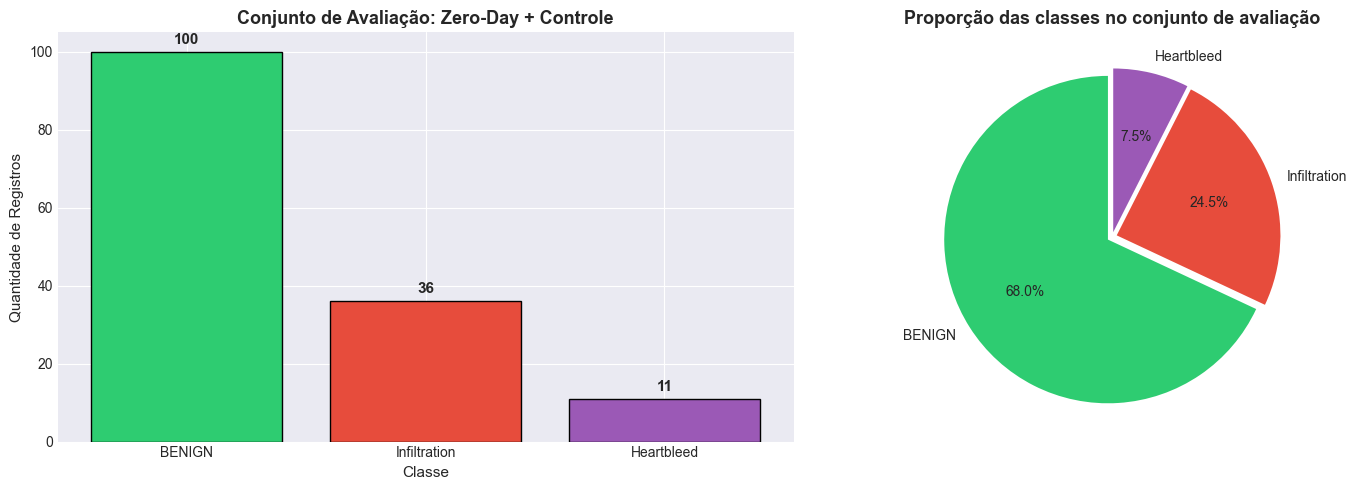

In [7]:
# gráfico comparativo incluindo o grupo de controle
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# cores: roxo/vermelho para zero-day, verde para controle benigno
mapa_cores = {
    'Heartbleed': '#9b59b6',
    'Infiltration': '#e74c3c',
    'BENIGN': '#2ecc71'
}
cores = [mapa_cores.get(c, "#95a5a6") for c in distribuicao_final.index]

# gráfico de barras
axes[0].bar(distribuicao_final.index, distribuicao_final.values,
            color=cores, edgecolor="black")
axes[0].set_title("Conjunto de Avaliação: Zero-Day + Controle",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Classe", fontsize=11)
axes[0].set_ylabel("Quantidade de Registros", fontsize=11)

for i, v in enumerate(distribuicao_final.values):
    axes[0].text(i, v + max(distribuicao_final.values) * 0.02,
                 f"{v:,}", ha="center", fontweight="bold", fontsize=11)

# gráfico de pizza
axes[1].pie(distribuicao_final.values, labels=distribuicao_final.index,
            autopct='%1.1f%%', colors=cores,
            startangle=90, explode=[0.03] * len(distribuicao_final))
axes[1].set_title("Proporção das classes no conjunto de avaliação",
                  fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

In [8]:
# perspectiva: o que foi usado no treino vs o que será usado agora
print("Perspectiva em relação ao treino:\n")
print("=" * 65)
print(f"{'Conjunto':<40} {'Registros':>15}")
print("=" * 65)
print(f"{'Treino (4 classes x 2.500)':<40} {'10,000':>15}")
print("-" * 65)
print(f"{'Heartbleed (zero-day, não visto)':<40} "
      f"{distribuicao_final.get('Heartbleed', 0):>15,}")
print(f"{'Infiltration (zero-day, não visto)':<40} "
      f"{distribuicao_final.get('Infiltration', 0):>15,}")
print(f"{'BENIGN (controle, não visto no treino)':<40} "
      f"{distribuicao_final.get('BENIGN', 0):>15,}")
print("-" * 65)
print(f"{'TOTAL conjunto de avaliação':<40} {len(df_avaliacao):>15,}")
print("=" * 65)

Perspectiva em relação ao treino:

Conjunto                                       Registros
Treino (4 classes x 2.500)                        10,000
-----------------------------------------------------------------
Heartbleed (zero-day, não visto)                      11
Infiltration (zero-day, não visto)                    36
BENIGN (controle, não visto no treino)               100
-----------------------------------------------------------------
TOTAL conjunto de avaliação                          147


In [9]:
# salvando o conjunto completo de avaliação
pasta_zero_day = '../dados/dados_processados/zero_day/'
os.makedirs(pasta_zero_day, exist_ok=True)

caminho_csv = os.path.join(pasta_zero_day, 'registros_avaliacao_zero_day_bruto.csv')
df_avaliacao.to_csv(caminho_csv, index=False)

tamanho_kb = os.path.getsize(caminho_csv) / 1024
print(f"Arquivo salvo:")
print(f"  {caminho_csv}")
print(f"  Tamanho: {tamanho_kb:.1f} KB")
print(f"  Formato: {df_avaliacao.shape}")
print(f"\nClasses incluídas:")
for classe, qtd in distribuicao_final.items():
    print(f"  • {classe}: {qtd:,} registros")

Arquivo salvo:
  ../dados/dados_processados/zero_day/registros_avaliacao_zero_day_bruto.csv
  Tamanho: 56.4 KB
  Formato: (147, 79)

Classes incluídas:
  • BENIGN: 100 registros
  • Infiltration: 36 registros
  • Heartbleed: 11 registros


In [11]:
print("=" * 65)
print("           RESUMO DA EXTRAÇÃO ZERO-DAY + CONTROLE")
print("=" * 65)
print(f"\n Dataset bruto carregado:         {len(df_total):,} registros")
print(f"\n ZERO-DAY (não visto no treino):")
for classe, qtd in df_zero_day['Label'].value_counts().items():
    print(f"     • {classe:25s}: {qtd:,} registros")
print(f"\n CONTROLE (BENIGN não visto no treino):")
print(f"     • BENIGN                   : {len(df_benign_controle):,} registros")
print(f"\n Total no conjunto de avaliação:  {len(df_avaliacao):,} registros")
print(f"\n Arquivo gerado:                  registros_avaliacao_zero_day_bruto.csv")
print("\n" + "=" * 65)


           RESUMO DA EXTRAÇÃO ZERO-DAY + CONTROLE

 Dataset bruto carregado:         2,830,743 registros

 ZERO-DAY (não visto no treino):
     • Infiltration             : 36 registros
     • Heartbleed               : 11 registros

 CONTROLE (BENIGN não visto no treino):
     • BENIGN                   : 100 registros

 Total no conjunto de avaliação:  147 registros

 Arquivo gerado:                  registros_avaliacao_zero_day_bruto.csv

